In [1]:
# In[1]:
# --- Step 0: Imports and Setup ---
import torch
import numpy as np
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# Import from our custom modules
from dataset.generate_training_data import prepare_dataloaders, get_adjacency_matrix_and_supports
from graph_wavenet import gwnet
from train import unscale_data, calculate_nse # Re-using functions from train.py

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
print(f"SHAP version being used: {shap.__version__}")
print(f"PyTorch version being used: {torch.__version__}")


SHAP version being used: 0.48.0
PyTorch version being used: 2.7.0+cu118


In [2]:
# --- Step 0: Configuration ---
class AnalysisConfig:
    # Data and Model Config
    seq_len = 30
    pred_len = 10
    
    # Paths
    PROCESSED_DATA_DIR = Path("dataset/processed_data_camels")
    ADJ_MATRIX_PATH = PROCESSED_DATA_DIR / "adjacency_matrix.pkl"
    STATIC_FEATURES_PATH = PROCESSED_DATA_DIR / "static_features_array.npy"
    SCALER_PATH = PROCESSED_DATA_DIR / "timeseries_node_scalers.pkl"
    MODEL_WEIGHTS_PATH = "weights/best_gwnet_model.pt"
    ANALYSIS_PLOTS_DIR = Path("plots/advanced_shap_analysis")
    
    # SHAP explainer config
    NUM_BACKGROUND_SAMPLES = 50  # Number of training samples for background dataset
    NUM_EXPLAIN_SAMPLES_GROUP = 50 # Number of test samples to explain for each group (high/low perf)
    NUM_EXPLAIN_SAMPLES_INDIVIDUAL = 20 # Number of test samples to explain for individual sites

    # Training Config (needed for dataloader)
    batch_size = 32
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15

    # Device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

config = AnalysisConfig()
config.ANALYSIS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)



In [3]:
# --- Helper Functions and Classes ---


def get_feature_names(static_features_path):
    """
    Constructs the list of feature names for plotting.
    """
    # Dynamic features are known
    dynamic_features = [
        'Discharge', 'Precipitation', 'Solar Radiation', 'Max Temperature', 
        'Min Temperature', 'Vapor Pressure'
    ]
    
    # Load static feature names from the processed CSV header
    try:
        static_df = pd.read_csv("dataset/data_camels/basin_characteristics.csv")
        # Use the same list of attributes as defined in the GNN paper
        static_cols_from_paper = [
            'p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow', 
            'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 
            'elev_mean', 'slope_mean', 'area_gages2', 'frac_forest', 'lai_max', 
            'lai_diff', 'gvf_max', 'gvf_diff', 'soil_depth_pelletier', 
            'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 
            'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 
            'geol_permeability', 'carbonate_rocks_frac'
        ]
        # Filter to ensure we only have columns that exist in the file
        static_features_names = [col for col in static_cols_from_paper if col in static_df.columns]
    except Exception as e:
        print(f"Warning: Could not load static feature names. Using generic names. Error: {e}")
        num_static = np.load(static_features_path).shape[1]
        static_features_names = [f'static_feat_{i}' for i in range(num_static)]
        
    return dynamic_features, static_features_names

class GwnetModelWrapper(torch.nn.Module):
    """
    Wraps the gwnet model to handle input permutation and select a single output for SHAP.
    This is adapted to handle both grouped and individual site analysis.
    """
    def __init__(self, model, node_index=None):
        super(GwnetModelWrapper, self).__init__()
        self.model = model
        self.node_index = node_index # If None, explains the mean output. If set, explains a specific node.

    def forward(self, x):
        x_permuted = x.permute(0, 3, 2, 1)
        output = self.model(x_permuted).squeeze(1)
        
        if self.node_index is not None:
            # Explain the prediction for a single, specific node
            return output[:, 0, self.node_index].unsqueeze(1)
        else:
            # Explain the average prediction across all nodes. This logic matches the user's provided wrapper.
            return output[:, 0, :].mean(dim=1).unsqueeze(1)



In [4]:

print("--- Loading pre-trained model and data ---")

train_loader, _, test_loader, adj_matrix = prepare_dataloaders(config=config)
x_sample, _ = next(iter(train_loader))
num_nodes = x_sample.shape[2]
num_input_features = x_sample.shape[3]
site_order = pd.read_csv("dataset/data_camels/basin_characteristics.csv")['site_no'].astype(str).tolist()

_, supports = get_adjacency_matrix_and_supports(config.ADJ_MATRIX_PATH, config.device)

model = gwnet(
    device=config.device, num_nodes=num_nodes,
    in_dim=num_input_features, out_dim=config.pred_len, supports=supports
).to(config.device)

try:
    model.load_state_dict(torch.load(config.MODEL_WEIGHTS_PATH, map_location=config.device))
    with open(config.SCALER_PATH, 'rb') as f:
        scalers = pickle.load(f)
    print("Successfully loaded model and scalers.")
except FileNotFoundError as e:
    print(f"ERROR: Could not load model or scalers. Please ensure training is complete. Details: {e}")
    # Stop execution if files aren't found
    model = None

if model is not None:
    model.eval()

wrapped_model = GwnetModelWrapper(model)

--- Loading pre-trained model and data ---
Loading processed data...
  Timeseries data: (12784, 671, 6)
  Static features array: (671, 27)
  Adjacency matrix shape: (671, 671)

Configuration: Using 1 time series (discharge only).
Configuration: Using static features.
Data split into Train (8948), Val (1918), Test (1918) sets.
Fitting scalers on training data for 671 nodes and 1 features individually...
  Scaling discharge (feature 0) using StandardScaler for each node...


  Node-and-feature-wise scaling complete.
  Saved scalers for all time series to dataset/processed_data_camels/timeseries_node_scalers.pkl
Scaled train data: [[[-0.45889487]
  [-0.13861134]
  [ 0.02144823]
  ...
  [ 1.45108494]
  [-0.32699966]
  [ 1.92275976]]

 [[-0.46754869]
  [-0.22180219]
  [-0.08195856]
  ...
  [ 0.86677901]
  [-0.32699966]
  [ 0.95876108]]

 [[-0.4762025 ]
  [-0.29574962]
  [-0.1792826 ]
  ...
  [ 0.47967633]
  [-0.32699966]
  [ 0.47936715]]

 ...

 [[-0.32562612]
  [-0.24583511]
  [-0.63214352]
  ...
  [-0.50341839]
  [-0.31327758]
  [-0.5356974 ]]

 [[-0.3469722 ]
  [-0.42146024]
  [-0.64126765]
  ...
  [-0.50487916]
  [-0.31399979]
  [-0.53778172]]

 [[-0.25985713]
  [-0.47692081]
  [-0.65343316]
  ...
  [-0.50633992]
  [-0.31472201]
  [-0.53882389]]]

--- Creating Training Sequences ---
Created sequences: X shape (8909, 30, 671, 28), Y shape (8909, 10, 671, 1)

--- Creating Validation Sequences ---
Created sequences: X shape (1879, 30, 671, 28), Y shape (1879

In [5]:

# In[5]:
# --- Step 2: Run Inference and Calculate NSE per Site ---
if model:
    print("\n--- Running inference on test set to calculate NSE scores ---")
    all_y_true = []
    all_y_pred = []
    
    with torch.no_grad():
        for x_batch, y_batch in tqdm(test_loader, desc="Inference"):
            x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)
            
            output = model(x_batch.permute(0, 3, 2, 1)).squeeze(1)
            y_target = y_batch.squeeze(-1)

            # Unscale for NSE calculation
            pred_unscaled = unscale_data(output.permute(0, 2, 1), scalers[0])
            true_unscaled = unscale_data(y_target.permute(0, 2, 1), scalers[0])
            
            all_y_pred.append(pred_unscaled.cpu())
            all_y_true.append(true_unscaled.cpu())

    all_y_true = torch.cat(all_y_true, dim=0)
    all_y_pred = torch.cat(all_y_pred, dim=0)
    
    # Calculate NSE for each node (site)
    nse_scores = {}
    for i in range(num_nodes):
        site_id = site_order[i]
        y_true_node = all_y_true[:, i, :].flatten()
        y_pred_node = all_y_pred[:, i, :].flatten()
        nse = calculate_nse(y_true_node, y_pred_node)
        nse_scores[site_id] = nse
    
    nse_df = pd.DataFrame(list(nse_scores.items()), columns=['site_no', 'nse']).set_index('site_no')
    nse_df = nse_df[nse_df["nse"] >= -1e4]
    print("NSE scores calculated for all sites.")
    print(nse_df['nse'].describe())




--- Running inference on test set to calculate NSE scores ---


Inference: 100%|██████████| 59/59 [02:45<00:00,  2.81s/it]

y_true: tensor([-410.4663, -410.4663, -410.4663,  ..., -410.4663, -410.4663,
        -410.4663])
y_pred: tensor([-440.2424, -347.0920, -341.4624,  ..., -291.0354, -280.7299,
        -266.1030])
numerator: tensor(1.6019e+08)
denominator: tensor(1.7500e-05)
y_true: tensor([-315.6450, -315.6450, -315.6450,  ..., -315.6450, -315.6450,
        -315.6450])
y_pred: tensor([-275.8086, -187.5883, -175.3772,  ..., -114.5256, -103.9531,
         -89.2790])
numerator: tensor(4.8274e+08)
denominator: tensor(0.)
NSE scores calculated for all sites.
count    669.000000
mean       0.297957
std        0.477219
min      -10.121592
25%        0.121324
50%        0.236860
75%        0.413378
max        0.941537
Name: nse, dtype: float64


In [6]:

# In[6]:
# --- Step 3: Segment Data by Performance ---
if model:
    print("\n--- Segmenting test data by performance ---")
    
    # Get all test data samples
    X_test_all = torch.cat([x for x, y in test_loader], dim=0)
    Y_test_all = torch.cat([y for x, y in test_loader], dim=0)
    
    # Find the median NSE to split the groups
    median_nse = nse_df['nse'].mean()
    high_perf_sites = nse_df[nse_df['nse'] >= median_nse].index.tolist()
    low_perf_sites = nse_df[nse_df['nse'] < median_nse].index.tolist()
    
    print(f"Performance threshold (median NSE): {median_nse:.4f}")
    print(f"High-performance sites: {len(high_perf_sites)}, Low-performance sites: {len(low_perf_sites)}")

    # Get the indices of these sites in our master site_order list
    high_perf_indices = [site_order.index(s) for s in high_perf_sites if s in site_order]
    low_perf_indices = [site_order.index(s) for s in low_perf_sites if s in site_order]

    # Sub-sample the test data for SHAP analysis to save time
    X_test_subset = X_test_all[:config.NUM_EXPLAIN_SAMPLES_GROUP]




--- Segmenting test data by performance ---


Performance threshold (median NSE): 0.2980
High-performance sites: 253, Low-performance sites: 416



--- Running SHAP Analysis for High Performance Group ---


/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: nconv
  warnings.warn(f"unrecognized nn.Module: {module_type}")


['Discharge', 'Precipitation', 'Solar Radiation', 'Max Temperature', 'Min Temperature', 'Vapor Pressure', 'p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'elev_mean', 'slope_mean', 'area_gages2', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'geol_permeability', 'carbonate_rocks_frac']


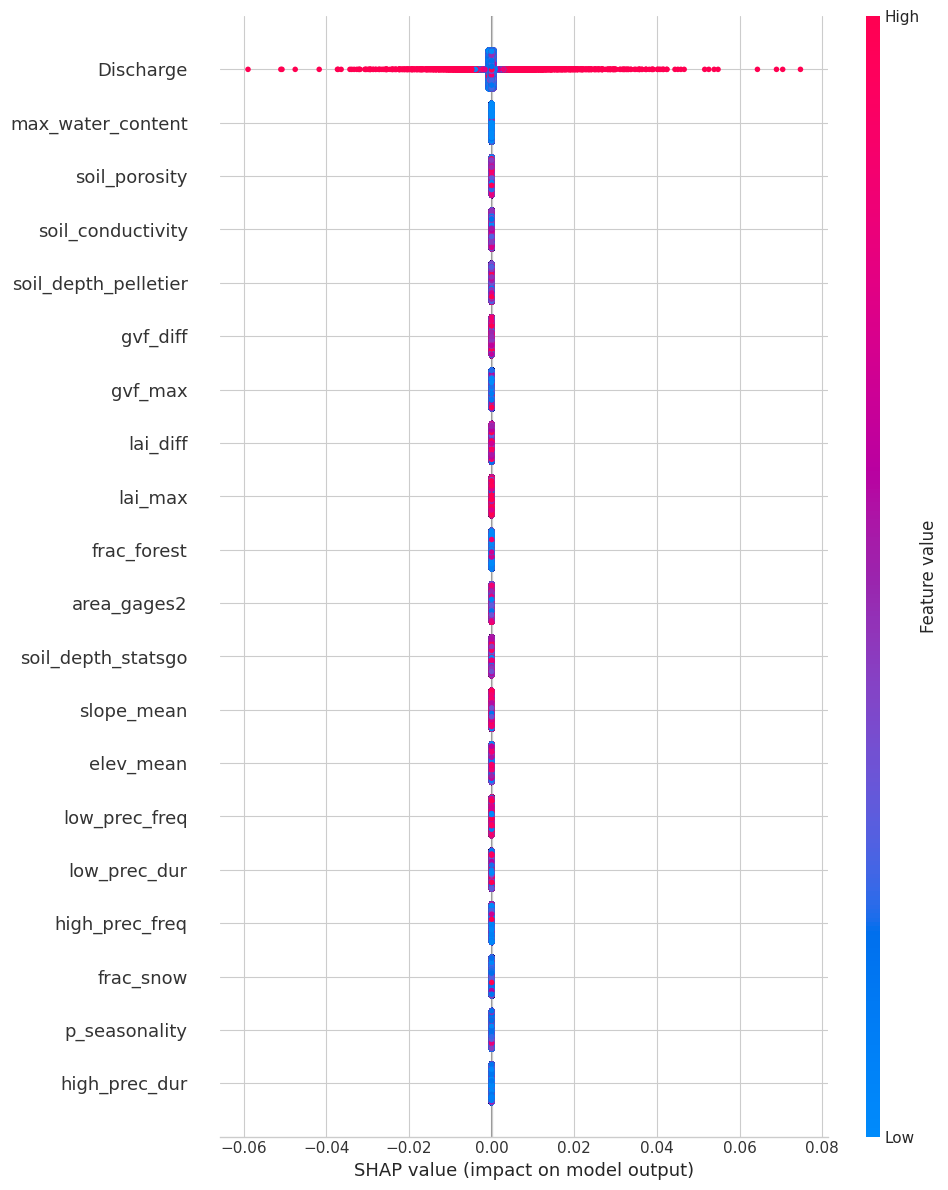

Saved High Performance SHAP plot to plots/advanced_shap_analysis/shap_summary_high_performance.png

--- Running SHAP Analysis for Low Performance Group ---


/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: nconv
  warnings.warn(f"unrecognized nn.Module: {module_type}")


['Discharge', 'Precipitation', 'Solar Radiation', 'Max Temperature', 'Min Temperature', 'Vapor Pressure', 'p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'elev_mean', 'slope_mean', 'area_gages2', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'geol_permeability', 'carbonate_rocks_frac']


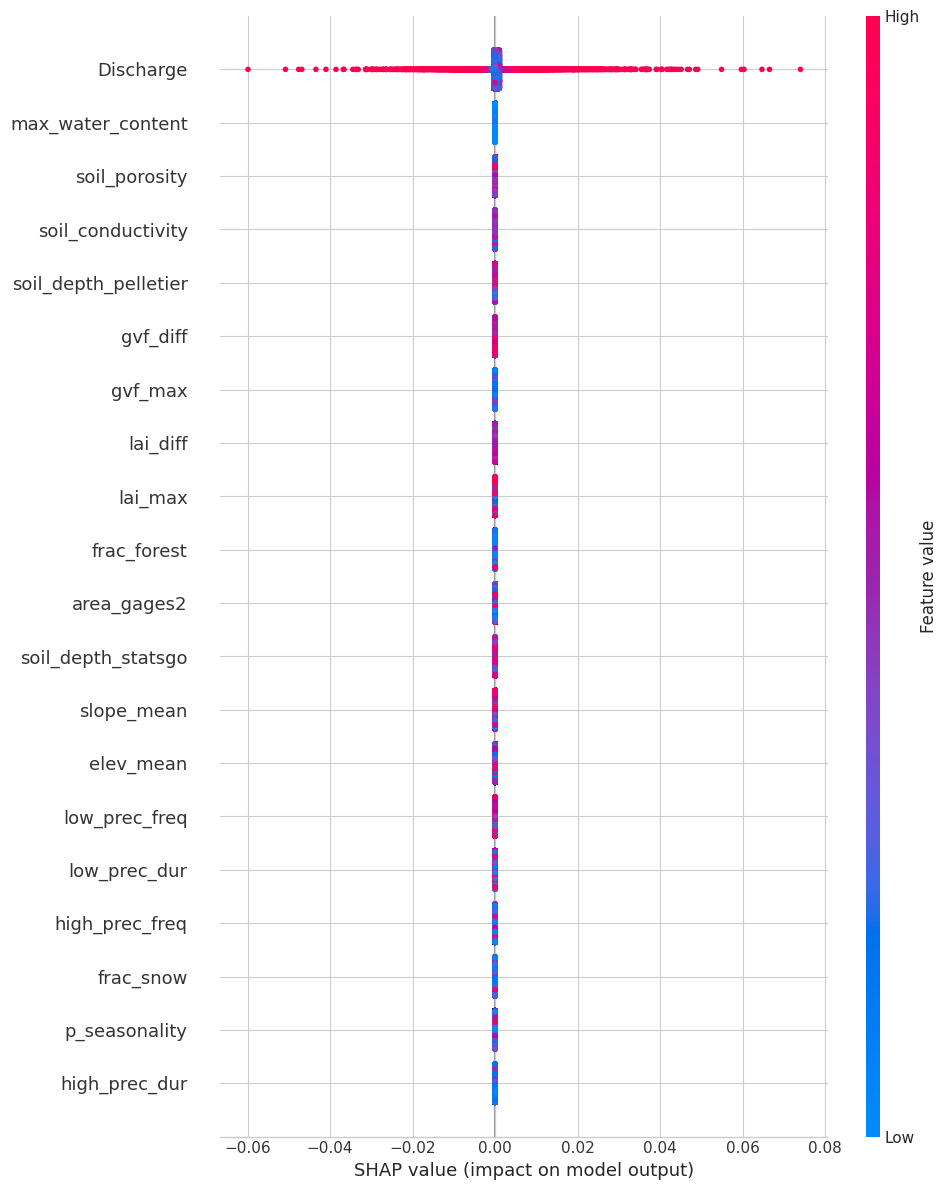

Saved Low Performance SHAP plot to plots/advanced_shap_analysis/shap_summary_low_performance.png


In [7]:

# In[7]:
# --- Step 4 & 5: SHAP Analysis for High and Low Performance Groups ---

def analyze_performance_group(group_name, group_indices, X_data):
    """Helper function to run SHAP analysis on a subset of nodes."""
    print(f"\n--- Running SHAP Analysis for {group_name} Group ---")
    
    # Get background data for explainer
    background_data = torch.cat([x for x, y in train_loader], dim=0)[:config.NUM_BACKGROUND_SAMPLES].to(config.device)
    
    explainer = shap.DeepExplainer(wrapped_model, background_data)
    shap_values = explainer.shap_values(X_data.to(config.device), check_additivity=False)
    
    # Reshape for plotting
    shap_values_reshaped = shap_values.reshape(-1, num_input_features)
    test_data_reshaped = X_data.cpu().numpy().reshape(-1, num_input_features)
    
    dynamic_feature_names, static_feature_names = get_feature_names(config.STATIC_FEATURES_PATH)
    feature_names = dynamic_feature_names + static_feature_names
    
    print(feature_names)
    
    # Generate and save plot
    shap.summary_plot(shap_values_reshaped, test_data_reshaped, feature_names=feature_names, show=False)
    plt.gcf().set_size_inches(10, 12)
    plt.tight_layout()
    save_path = config.ANALYSIS_PLOTS_DIR / f"shap_summary_{group_name.lower().replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved {group_name} SHAP plot to {save_path}")


if model:
    # Run analysis for both groups
    analyze_performance_group("High Performance", high_perf_indices, X_test_subset)
    analyze_performance_group("Low Performance", low_perf_indices, X_test_subset)




--- Running SHAP Analysis for Individual Site: 10244950 ---


/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: nconv
  warnings.warn(f"unrecognized nn.Module: {module_type}")


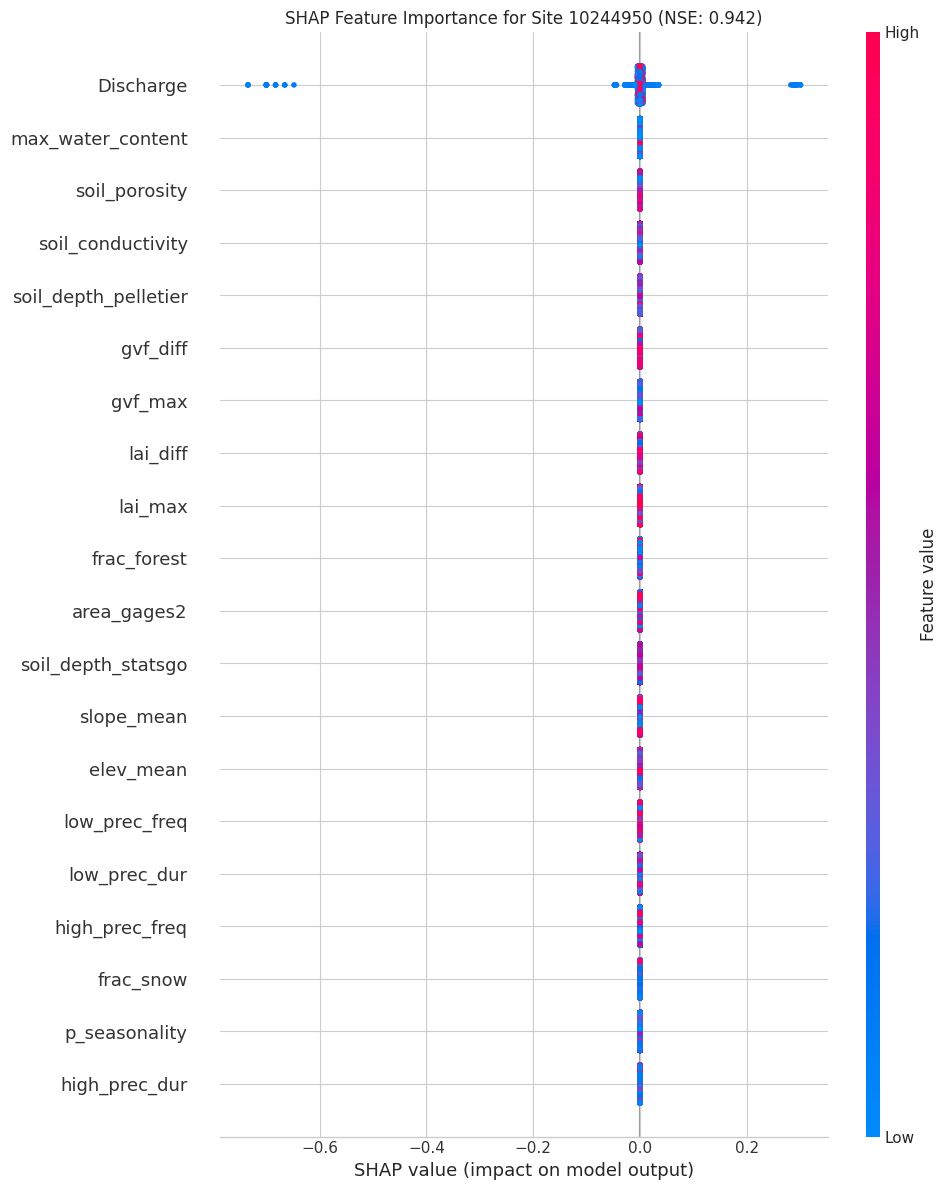

Saved individual SHAP plot for site 10244950 to plots/advanced_shap_analysis/shap_summary_site_10244950.png

--- Running SHAP Analysis for Individual Site: 8190500 ---


/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: nconv
  warnings.warn(f"unrecognized nn.Module: {module_type}")


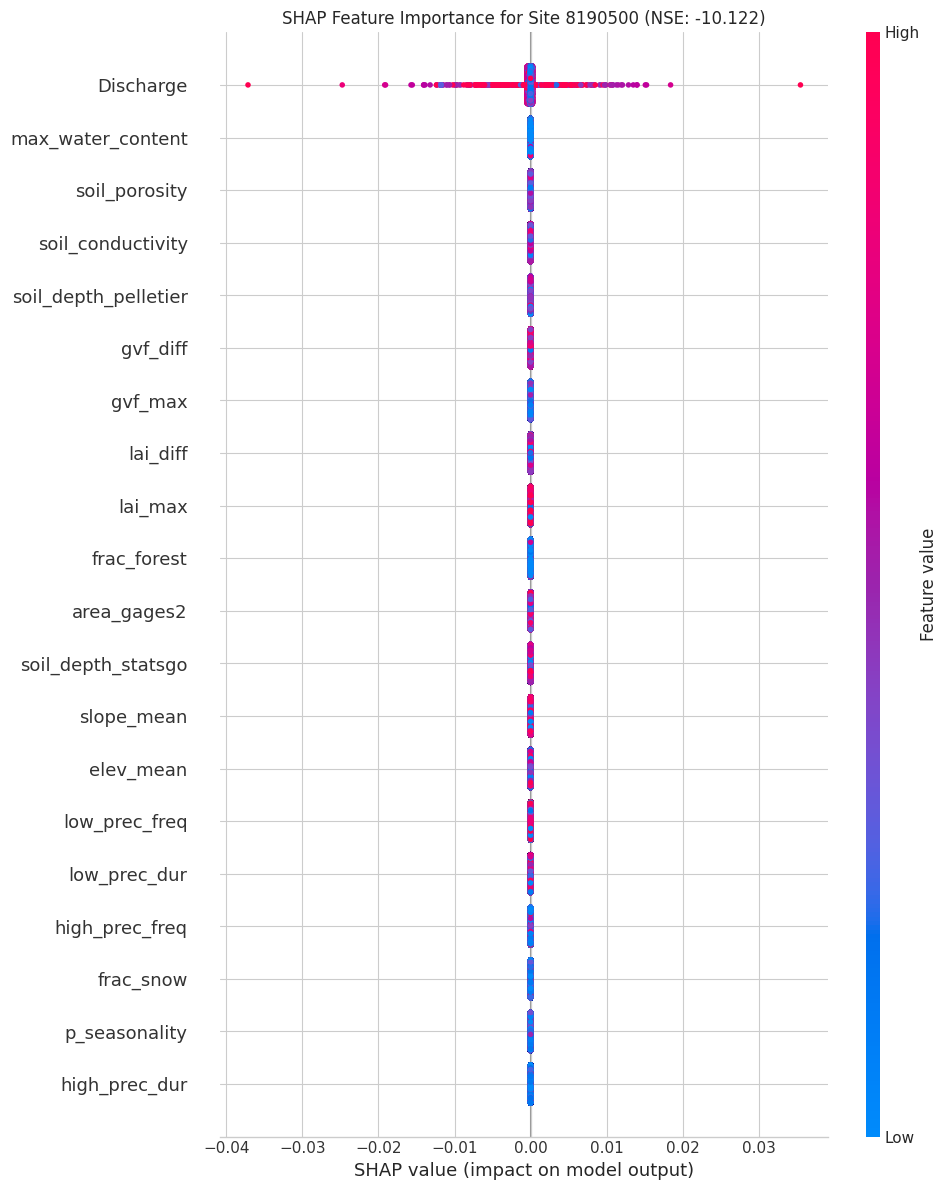

Saved individual SHAP plot for site 8190500 to plots/advanced_shap_analysis/shap_summary_site_8190500.png

--- Advanced SHAP Analysis Complete ---


In [9]:

# In[8]:
# --- Step 6: SHAP Analysis for Individual Sites ---

def analyze_individual_site(site_id, X_data):
    """Helper function to run SHAP analysis for a single, specific site."""
    print(f"\n--- Running SHAP Analysis for Individual Site: {site_id} ---")
    
    try:
        node_idx = site_order.index(site_id)
    except ValueError:
        print(f"Site {site_id} not in site_order list. Skipping.")
        return
        
    # Use the specific model wrapper for a single node
    single_node_wrapper = GwnetModelWrapper(model, node_index=node_idx)
    
    # Get background data for explainer
    background_data = torch.cat([x for x, y in train_loader], dim=0)[:config.NUM_BACKGROUND_SAMPLES].to(config.device)
    
    explainer = shap.DeepExplainer(single_node_wrapper, background_data)
    shap_values = explainer.shap_values(X_data.to(config.device), check_additivity=False)
    
    # Reshape for plotting
    shap_values_reshaped = shap_values.reshape(-1, num_input_features)
    test_data_reshaped = X_data.cpu().numpy().reshape(-1, num_input_features)
    dynamic_feature_names, static_feature_names = get_feature_names(config.STATIC_FEATURES_PATH)
    feature_names = dynamic_feature_names + static_feature_names
    
    # Generate and save plot
    shap.summary_plot(shap_values_reshaped, test_data_reshaped, feature_names=feature_names, show=False)
    plt.gcf().set_size_inches(10, 12)
    plt.title(f"SHAP Feature Importance for Site {site_id} (NSE: {nse_df.loc[site_id, 'nse']:.3f})")
    plt.tight_layout()
    save_path = config.ANALYSIS_PLOTS_DIR / f"shap_summary_site_{site_id}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved individual SHAP plot for site {site_id} to {save_path}")

if model:
    # Select one high and one low performing site to analyze
    site_high_perf = nse_df['nse'].idxmax()
    site_low_perf = nse_df['nse'].idxmin()

    X_test_individual_subset = X_test_all[:config.NUM_EXPLAIN_SAMPLES_INDIVIDUAL]

    analyze_individual_site(site_high_perf, X_test_individual_subset)
    analyze_individual_site(site_low_perf, X_test_individual_subset)

print("\n--- Advanced SHAP Analysis Complete ---")